# Load Example Images

In [1]:
import requests
from PIL import Image
from io import BytesIO
import os

# Output folder
output_folder = "/kaggle/working/"
os.makedirs(output_folder, exist_ok=True)

# Number of images
n = 9

for i in range(1, n + 1):
    url = "https://picsum.photos/300"

    res = requests.get(url)
    img = Image.open(BytesIO(res.content)).convert("RGB")

    save_path = os.path.join(output_folder, f"img{i}.jpg")
    img.save(save_path, "JPEG")

print("Saved 9 images from API to /kaggle/working/")

Saved 9 images from API to /kaggle/working/


# Main Code (Rafat's Area for Greyscale Color Palette)

## Grayscale Quantization Formula (Color Palette Reduction)

### Formula

$$
\text{new\_pixel} = \left\lfloor \frac{\text{pixel}}{256 / N} \right\rfloor \times \left(\frac{256}{N}\right)
$$

### Where

- **pixel**: Original pixel value (0–255)  
- **N**: Palette size (number of gray levels)  

---

### Example

For $N = 4$:

$$
\text{step} = \frac{256}{4} = 64
$$

Output values:
$$
0,\ 64,\ 128,\ 192
$$

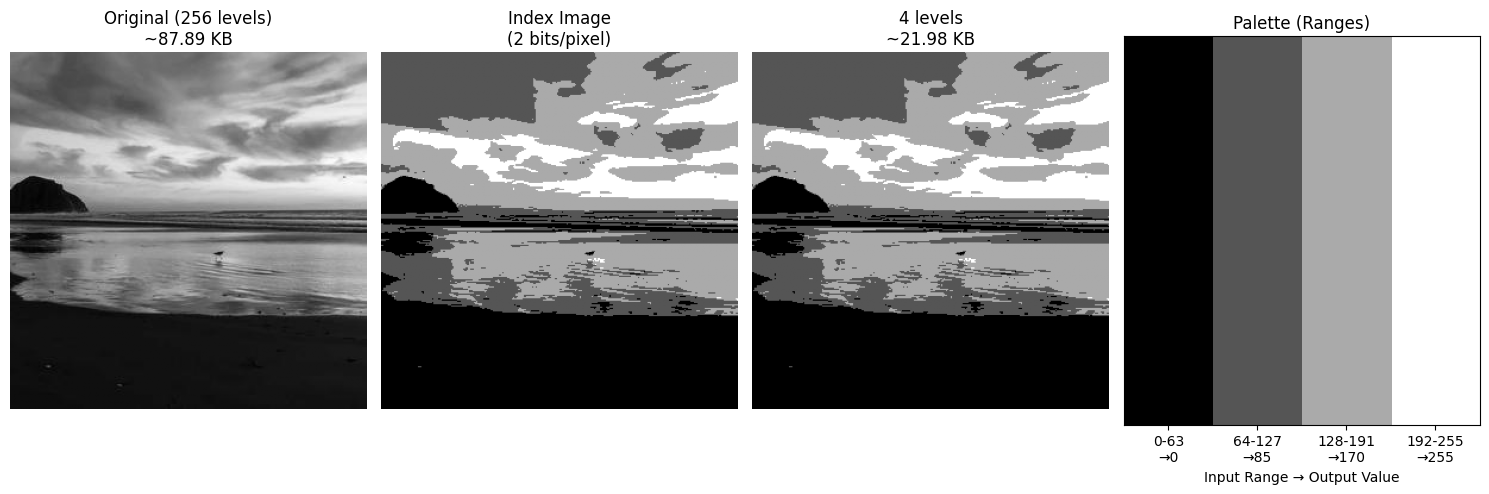

Palette values: [  0  85 170 255]
Bits per pixel (index): 2
Original Size: 87.89 KB
Quantized Size (Index + Palette): 21.98 KB
Compression: 75.00% reduction


In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ===== INPUT =====
palette_size = 4

# Load image and convert to grayscale
img = Image.open('img1.jpg').convert('L')
img_np = np.array(img)

# ===== CREATE PALETTE =====
palette = np.linspace(0, 255, palette_size, dtype=np.uint8)

# ===== CREATE INDEX IMAGE =====
step = 256 // palette_size
index_img = img_np // step

# ===== RECONSTRUCT IMAGE =====
quantized_np = palette[index_img]

# ===== SIZE ESTIMATION =====
h, w = img_np.shape
original_size_kb = (h * w * 8) / (8 * 1024)

bits_per_pixel = int(np.ceil(np.log2(palette_size)))
index_size = (h * w * bits_per_pixel) / (8 * 1024)
palette_size_kb = (palette_size * 8) / (8 * 1024)

quantized_size_kb = index_size + palette_size_kb

# ===== CREATE PALETTE IMAGE =====
palette_img = np.tile(palette, (60, 1))

# ===== CREATE RANGE LABELS =====
ranges = []
for i in range(palette_size):
    start = i * step
    end = min((i + 1) * step - 1, 255)
    ranges.append(f"{start}-{end}\n→{palette[i]}")

# ===== DISPLAY =====
plt.figure(figsize=(15,5))

# Original Image
plt.subplot(1,4,1)
plt.imshow(img_np, cmap='gray')
plt.title(f"Original (256 levels)\n~{original_size_kb:.2f} KB")
plt.axis('off')

# Index Image
plt.subplot(1,4,2)
plt.imshow(index_img, cmap='gray')
plt.title(f"Index Image\n({bits_per_pixel} bits/pixel)")
plt.axis('off')

# Quantized Image
plt.subplot(1,4,3)
plt.imshow(quantized_np, cmap='gray')
plt.title(f"{palette_size} levels\n~{quantized_size_kb:.2f} KB")
plt.axis('off')

# Palette with Range Mapping
plt.subplot(1,4,4)
plt.imshow(palette_img, cmap='gray', aspect='auto')
plt.title("Palette (Ranges)")
plt.xticks(range(palette_size), ranges)
plt.yticks([])
plt.xlabel("Input Range → Output Value")

plt.tight_layout()
plt.show()

# ===== PRINT DETAILS =====
print("Palette values:", palette)
print("Bits per pixel (index):", bits_per_pixel)
print(f"Original Size: {original_size_kb:.2f} KB")
print(f"Quantized Size (Index + Palette): {quantized_size_kb:.2f} KB")
print(f"Compression: {(1 - quantized_size_kb/original_size_kb)*100:.2f}% reduction")

# Main Code (Pravesh's Area)

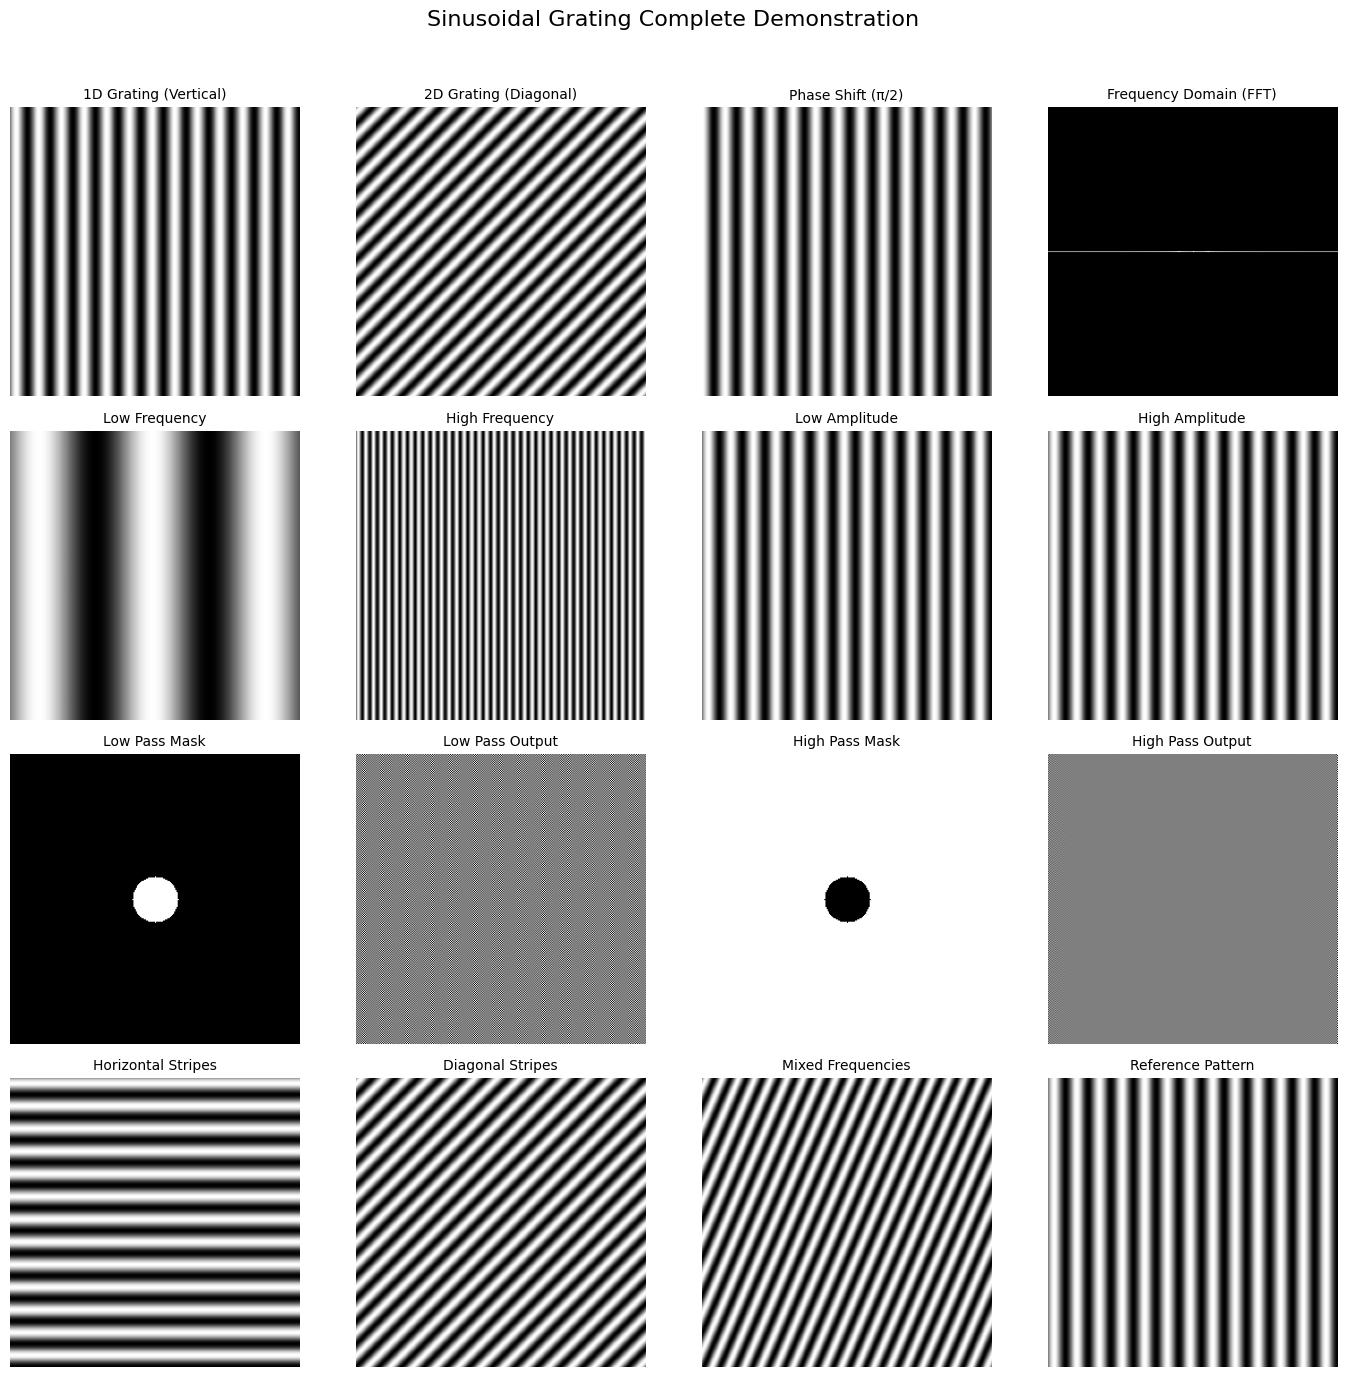

In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.fft import fft2, fftshift, ifft2

# # ----------------------------
# # PARAMETERS (CHANGE TO EXPERIMENT)
# # ----------------------------
# size = 256              # image size
# A = 128                 # average intensity
# B = 100                 # amplitude (contrast)
# fx = 0.05               # frequency in x
# fy = 0.0                # frequency in y (0 for 1D)
# phi = 0                 # phase shift (radians)

# # ----------------------------
# # GENERATE COORDINATES
# # ----------------------------
# x = np.arange(size)
# y = np.arange(size)
# X, Y = np.meshgrid(x, y)

# # ----------------------------
# # SINUSOIDAL GRATING
# # ----------------------------
# grating = A + B * np.sin(2 * np.pi * (fx * X + fy * Y) + phi)

# # ----------------------------
# # NORMALIZE FOR DISPLAY
# # ----------------------------
# grating = np.clip(grating, 0, 255)

# # ----------------------------
# # FFT (FREQUENCY DOMAIN)
# # ----------------------------
# fft_img = fftshift(fft2(grating))
# magnitude = np.log(1 + np.abs(fft_img))

# # ----------------------------
# # FILTERS
# # ----------------------------
# def low_pass_filter(shape, radius):
#     h, w = shape
#     Y, X = np.ogrid[:h, :w]
#     center = (h//2, w//2)
#     dist = (X - center[1])**2 + (Y - center[0])**2
#     return dist <= radius**2

# def high_pass_filter(shape, radius):
#     return ~low_pass_filter(shape, radius)

# lp_mask = low_pass_filter(grating.shape, 20)
# hp_mask = high_pass_filter(grating.shape, 20)

# # Apply filters
# lp_result = np.real(ifft2(fft_img * lp_mask))
# hp_result = np.real(ifft2(fft_img * hp_mask))

# # ----------------------------
# # PLOTTING ALL RESULTS
# # ----------------------------
# plt.figure(figsize=(12,10))

# plt.subplot(2,3,1)
# plt.title("Sinusoidal Grating")
# plt.imshow(grating, cmap='gray')
# plt.axis('off')

# plt.subplot(2,3,2)
# plt.title("Frequency Domain (FFT)")
# plt.imshow(magnitude, cmap='gray')
# plt.axis('off')

# plt.subplot(2,3,3)
# plt.title("Low Pass Filter Output")
# plt.imshow(lp_result, cmap='gray')
# plt.axis('off')

# plt.subplot(2,3,4)
# plt.title("High Pass Filter Output")
# plt.imshow(hp_result, cmap='gray')
# plt.axis('off')

# # Change orientation example
# grating_diag = A + B * np.sin(2 * np.pi * (0.05 * X + 0.05 * Y))
# plt.subplot(2,3,5)
# plt.title("Diagonal Orientation")
# plt.imshow(grating_diag, cmap='gray')
# plt.axis('off')

# # Phase shift example
# grating_phase = A + B * np.sin(2 * np.pi * (fx * X) + np.pi/2)
# plt.subplot(2,3,6)
# plt.title("Phase Shifted")
# plt.imshow(grating_phase, cmap='gray')
# plt.axis('off')

# plt.tight_layout()
# plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift, ifft2

# ==============================
# PARAMETERS (EDIT FREELY)
# ==============================
size = 256
A = 128         # Average intensity
B = 100         # Amplitude (contrast)
fx = 0.05       # Frequency X
fy = 0.0        # Frequency Y (0 = 1D)
phi = 0         # Phase

# ==============================
# GRID
# ==============================
x = np.arange(size)
y = np.arange(size)
X, Y = np.meshgrid(x, y)

# ==============================
# GENERATE GRATINGS
# ==============================
def generate_grating(A, B, fx, fy, phi):
    return np.clip(A + B * np.sin(2*np.pi*(fx*X + fy*Y) + phi), 0, 255)

grating_1D = generate_grating(A, B, fx, 0, phi)
grating_2D = generate_grating(A, B, fx, fx, phi)
grating_phase = generate_grating(A, B, fx, 0, np.pi/2)
grating_low_freq = generate_grating(A, B, 0.01, 0, 0)
grating_high_freq = generate_grating(A, B, 0.15, 0, 0)
grating_low_amp = generate_grating(A, 30, fx, 0, 0)
grating_high_amp = generate_grating(A, 120, fx, 0, 0)

# ==============================
# FFT FUNCTION
# ==============================
def get_fft(img):
    f = fftshift(fft2(img))
    return np.log(1 + np.abs(f)), f

fft_mag, fft_complex = get_fft(grating_1D)

# ==============================
# FILTERS
# ==============================
def circular_mask(shape, radius, high_pass=False):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    center = (h//2, w//2)
    dist = (X - center[1])**2 + (Y - center[0])**2
    mask = dist <= radius**2
    return ~mask if high_pass else mask

lp_mask = circular_mask(grating_1D.shape, 20)
hp_mask = circular_mask(grating_1D.shape, 20, high_pass=True)

lp_result = np.real(ifft2(fft_complex * lp_mask))
hp_result = np.real(ifft2(fft_complex * hp_mask))

# ==============================
# PLOTTING (NO OVERLAP + CLEAN)
# ==============================
fig, axs = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("Sinusoidal Grating Complete Demonstration", fontsize=16)

def show(ax, img, title):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Row 1: Basic
show(axs[0,0], grating_1D, "1D Grating (Vertical)")
show(axs[0,1], grating_2D, "2D Grating (Diagonal)")
show(axs[0,2], grating_phase, "Phase Shift (π/2)")
show(axs[0,3], fft_mag, "Frequency Domain (FFT)")

# Row 2: Frequency
show(axs[1,0], grating_low_freq, "Low Frequency")
show(axs[1,1], grating_high_freq, "High Frequency")
show(axs[1,2], grating_low_amp, "Low Amplitude")
show(axs[1,3], grating_high_amp, "High Amplitude")

# Row 3: Filters
show(axs[2,0], lp_mask, "Low Pass Mask")
show(axs[2,1], lp_result, "Low Pass Output")
show(axs[2,2], hp_mask, "High Pass Mask")
show(axs[2,3], hp_result, "High Pass Output")

# Row 4: Orientation variations
grating_horizontal = generate_grating(A, B, 0, fx, 0)
grating_diagonal = generate_grating(A, B, fx, fx, 0)
grating_mixed = generate_grating(A, B, 0.07, 0.03, 0)

show(axs[3,0], grating_horizontal, "Horizontal Stripes")
show(axs[3,1], grating_diagonal, "Diagonal Stripes")
show(axs[3,2], grating_mixed, "Mixed Frequencies")
show(axs[3,3], grating_1D, "Reference Pattern")

# Layout fix (IMPORTANT)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Main Code (Rafat's Area for RGB Color Palette)

In [4]:
# from PIL import Image
# import numpy as np
# import matplotlib.pyplot as plt

# # ===== INPUT =====
# R_levels = 9
# G_levels = 4
# B_levels = 2

# # Load image
# img = Image.open('img1.jpg').convert('RGB')
# img_np = np.array(img)

# # Split channels
# R = img_np[:, :, 0]
# G = img_np[:, :, 1]
# B = img_np[:, :, 2]

# # ===== CREATE PALETTES =====
# palette_R = np.linspace(0, 255, R_levels, dtype=np.uint8)
# palette_G = np.linspace(0, 255, G_levels, dtype=np.uint8)
# palette_B = np.linspace(0, 255, B_levels, dtype=np.uint8)

# # ===== CREATE INDEX IMAGES =====
# step_R = 256 // R_levels
# step_G = 256 // G_levels
# step_B = 256 // B_levels

# R_idx = R // step_R
# G_idx = G // step_G
# B_idx = B // step_B

# # ===== RECONSTRUCT IMAGE =====
# R_q = palette_R[R_idx]
# G_q = palette_G[G_idx]
# B_q = palette_B[B_idx]

# quantized_np = np.stack([R_q, G_q, B_q], axis=2)

# # ===== SIZE ESTIMATION =====
# h, w, _ = img_np.shape
# original_size_kb = (h * w * 24) / (8 * 1024)

# bits_R = int(np.ceil(np.log2(R_levels)))
# bits_G = int(np.ceil(np.log2(G_levels)))
# bits_B = int(np.ceil(np.log2(B_levels)))
# bits_per_pixel = bits_R + bits_G + bits_B

# index_size = (h * w * bits_per_pixel) / (8 * 1024)
# palette_size_kb = ((R_levels + G_levels + B_levels) * 8) / (8 * 1024)
# quantized_size_kb = index_size + palette_size_kb

# total_colors = R_levels * G_levels * B_levels

# # ===== CREATE PALETTE VISUALS =====
# palette_R_img = np.tile(palette_R, (30, 1))
# palette_G_img = np.tile(palette_G, (30, 1))
# palette_B_img = np.tile(palette_B, (30, 1))

# # ===== CREATE RANGE LABELS =====
# def create_ranges(levels, step, palette):
#     labels = []
#     for i in range(levels):
#         start = i * step
#         end = min((i + 1) * step - 1, 255)
#         labels.append(f"{start}-{end}\n→{palette[i]}")
#     return labels

# ranges_R = create_ranges(R_levels, step_R, palette_R)
# ranges_G = create_ranges(G_levels, step_G, palette_G)
# ranges_B = create_ranges(B_levels, step_B, palette_B)

# # ===== DISPLAY (ONE ROW, WIDE & SHORT) =====
# plt.figure(figsize=(20,3))

# # Original
# plt.subplot(1,5,1)
# plt.imshow(img_np)
# plt.title("Original")
# plt.axis('off')

# # Quantized
# plt.subplot(1,5,2)
# plt.imshow(quantized_np)
# plt.title(f"Quantized\n{total_colors} colors")
# plt.axis('off')

# # ===== R Palette =====
# plt.subplot(1,5,3)
# plt.imshow(palette_R_img, cmap='Reds', aspect='auto')
# plt.title("R")

# xR = np.arange(R_levels)
# y_center = palette_R_img.shape[0] // 2
# plt.scatter(xR, [y_center]*R_levels, s=20)

# for i in range(R_levels + 1):
#     plt.axvline(i - 0.5, linewidth=0.8)

# plt.xticks(range(R_levels), ranges_R, fontsize=7)
# plt.yticks([])

# # ===== G Palette =====
# plt.subplot(1,5,4)
# plt.imshow(palette_G_img, cmap='Greens', aspect='auto')
# plt.title("G")

# xG = np.arange(G_levels)
# y_center = palette_G_img.shape[0] // 2
# plt.scatter(xG, [y_center]*G_levels, s=20)

# for i in range(G_levels + 1):
#     plt.axvline(i - 0.5, linewidth=0.8)

# plt.xticks(range(G_levels), ranges_G, fontsize=7)
# plt.yticks([])

# # ===== B Palette =====
# plt.subplot(1,5,5)
# plt.imshow(palette_B_img, cmap='Blues', aspect='auto')
# plt.title("B")

# xB = np.arange(B_levels)
# y_center = palette_B_img.shape[0] // 2
# plt.scatter(xB, [y_center]*B_levels, s=20)

# for i in range(B_levels + 1):
#     plt.axvline(i - 0.5, linewidth=0.8)

# plt.xticks(range(B_levels), ranges_B, fontsize=7)
# plt.yticks([])

# plt.tight_layout()
# plt.show()

# # ===== PRINT DETAILS =====
# print("R Palette:", palette_R)
# print("G Palette:", palette_G)
# print("B Palette:", palette_B)
# print("Bits per pixel:", bits_per_pixel)
# print(f"Original Size: {original_size_kb:.2f} KB")
# print(f"Quantized Size: {quantized_size_kb:.2f} KB")
# print(f"Compression: {(1 - quantized_size_kb/original_size_kb)*100:.2f}% reduction")

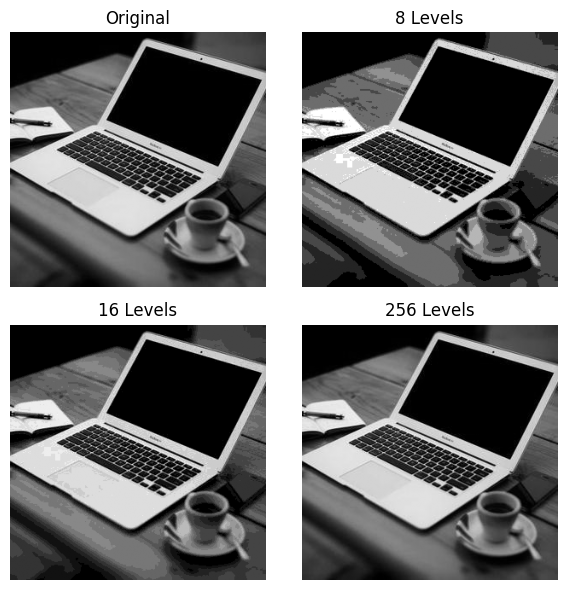

===== SIZE STATISTICS =====
Original Image Size: 87.89 KB (8 bits per pixel)

8 Levels -> Bits/Pixel: 3, Size: 32.97 KB
16 Levels -> Bits/Pixel: 4, Size: 43.96 KB
256 Levels -> Bits/Pixel: 8, Size: 88.14 KB


In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ===== LOAD IMAGE =====
img = Image.open('img3.jpg').convert('L')
img_np = np.array(img)

h, w = img_np.shape

# ===== FUNCTION =====
def quantize_image(img_np, palette_size):
    palette = np.linspace(0, 255, palette_size, dtype=np.uint8)
    step = 256 // palette_size
    index_img = img_np // step
    index_img = np.clip(index_img, 0, palette_size - 1)
    quantized = palette[index_img]

    # ===== SIZE CALCULATION =====
    bits_per_pixel = int(np.ceil(np.log2(palette_size)))
    index_size_kb = (h * w * bits_per_pixel) / (8 * 1024)
    palette_size_kb = (palette_size * 8) / (8 * 1024)
    total_size_kb = index_size_kb + palette_size_kb

    return quantized, total_size_kb, bits_per_pixel

# ===== ORIGINAL SIZE =====
original_size_kb = (h * w * 8) / (8 * 1024)

# ===== QUANTIZATION =====
q16, size16, bpp16 = quantize_image(img_np, 8)
q64, size64, bpp64 = quantize_image(img_np, 16)
q256, size256, bpp256 = quantize_image(img_np, 256)

# ===== PLOTTING =====
plt.figure(figsize=(6, 6))

plt.subplot(2, 2, 1)
plt.imshow(img_np, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(q16, cmap='gray')
plt.title("8 Levels")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(q64, cmap='gray')
plt.title("16 Levels")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(q256, cmap='gray')
plt.title("256 Levels")
plt.axis('off')

plt.tight_layout()
plt.show()

# ===== PRINT STATISTICS =====
print("===== SIZE STATISTICS =====")
print(f"Original Image Size: {original_size_kb:.2f} KB (8 bits per pixel)\n")

print(f"8 Levels -> Bits/Pixel: {bpp16}, Size: {size16:.2f} KB")
print(f"16 Levels -> Bits/Pixel: {bpp64}, Size: {size64:.2f} KB")
print(f"256 Levels -> Bits/Pixel: {bpp256}, Size: {size256:.2f} KB")

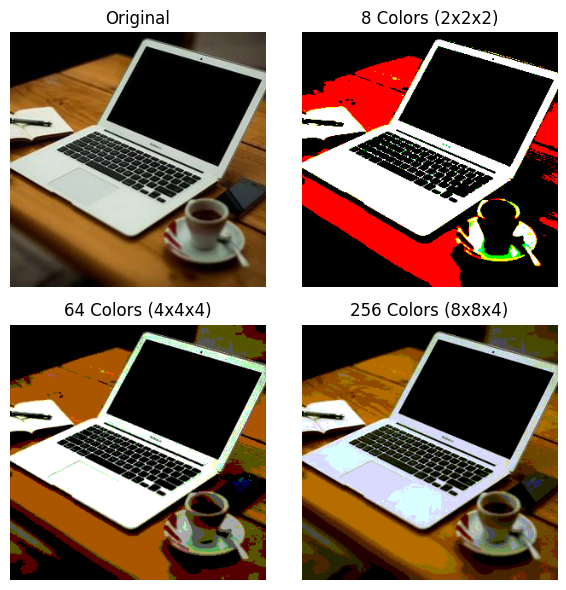

===== SIZE STATISTICS =====
Original Image Size: 263.67 KB (24 bits per pixel)

8 Colors   -> Bits/Pixel: 3, Colors: 8, Size: 32.96 KB
64 Colors  -> Bits/Pixel: 6, Colors: 64, Size: 65.93 KB
256 Colors -> Bits/Pixel: 8, Colors: 256, Size: 87.91 KB


In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ===== LOAD IMAGE =====
img = Image.open('img3.jpg').convert('RGB')
img_np = np.array(img)

h, w, _ = img_np.shape

# ===== FUNCTION =====
def quantize_rgb(img_np, R_levels, G_levels, B_levels):
    R = img_np[:, :, 0]
    G = img_np[:, :, 1]
    B = img_np[:, :, 2]

    palette_R = np.linspace(0, 255, R_levels, dtype=np.uint8)
    palette_G = np.linspace(0, 255, G_levels, dtype=np.uint8)
    palette_B = np.linspace(0, 255, B_levels, dtype=np.uint8)

    step_R = 256 // R_levels
    step_G = 256 // G_levels
    step_B = 256 // B_levels

    R_idx = np.clip(R // step_R, 0, R_levels - 1)
    G_idx = np.clip(G // step_G, 0, G_levels - 1)
    B_idx = np.clip(B // step_B, 0, B_levels - 1)

    R_q = palette_R[R_idx]
    G_q = palette_G[G_idx]
    B_q = palette_B[B_idx]

    quantized = np.stack([R_q, G_q, B_q], axis=2)

    # ===== SIZE CALCULATION =====
    bits_R = int(np.ceil(np.log2(R_levels)))
    bits_G = int(np.ceil(np.log2(G_levels)))
    bits_B = int(np.ceil(np.log2(B_levels)))
    bits_per_pixel = bits_R + bits_G + bits_B

    index_size_kb = (h * w * bits_per_pixel) / (8 * 1024)
    palette_size_kb = ((R_levels + G_levels + B_levels) * 8) / (8 * 1024)
    total_size_kb = index_size_kb + palette_size_kb

    total_colors = R_levels * G_levels * B_levels

    return quantized, total_size_kb, bits_per_pixel, total_colors


# ===== ORIGINAL SIZE =====
original_size_kb = (h * w * 24) / (8 * 1024)

# ===== QUANTIZATION =====
q8, size8, bpp8, colors8 = quantize_rgb(img_np, 2, 2, 2)
q64, size64, bpp64, colors64 = quantize_rgb(img_np, 4, 4, 4)
q256, size256, bpp256, colors256 = quantize_rgb(img_np, 8, 8, 4)

# ===== PLOT =====
plt.figure(figsize=(6, 6))

plt.subplot(2, 2, 1)
plt.imshow(img_np)
plt.title("Original")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(q8)
plt.title("8 Colors (2x2x2)")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(q64)
plt.title("64 Colors (4x4x4)")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(q256)
plt.title("256 Colors (8x8x4)")
plt.axis('off')

plt.tight_layout()
plt.show()

# ===== PRINT STATS =====
print("===== SIZE STATISTICS =====")
print(f"Original Image Size: {original_size_kb:.2f} KB (24 bits per pixel)\n")

print(f"8 Colors   -> Bits/Pixel: {bpp8}, Colors: {colors8}, Size: {size8:.2f} KB")
print(f"64 Colors  -> Bits/Pixel: {bpp64}, Colors: {colors64}, Size: {size64:.2f} KB")
print(f"256 Colors -> Bits/Pixel: {bpp256}, Colors: {colors256}, Size: {size256:.2f} KB")

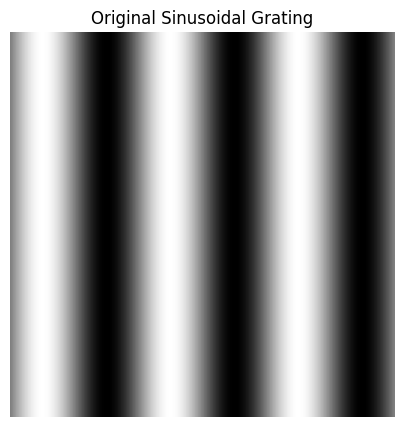

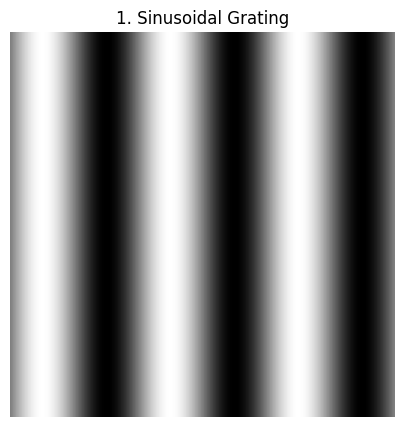

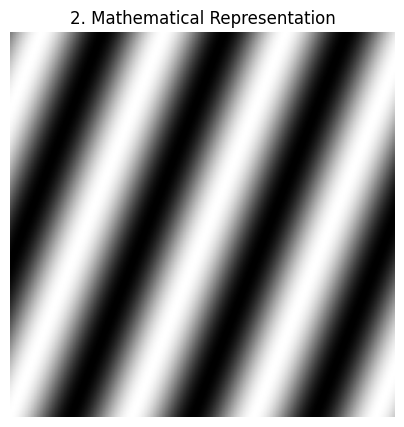

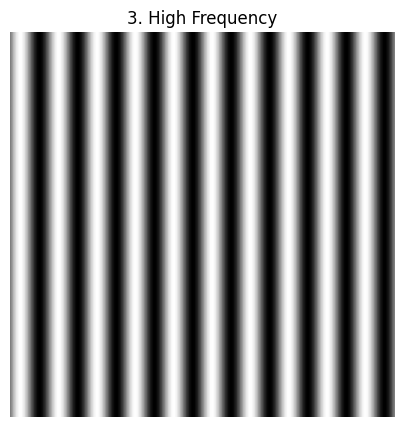

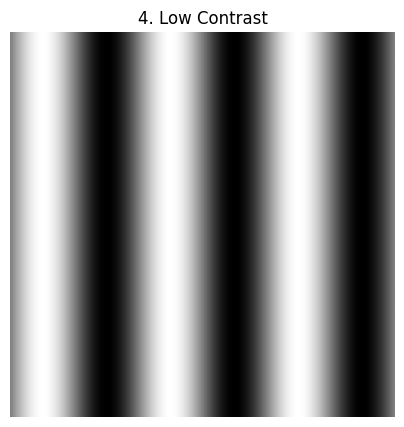

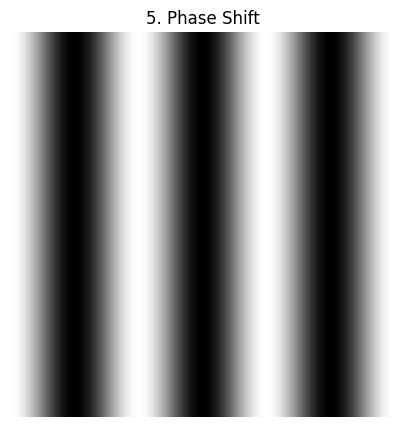

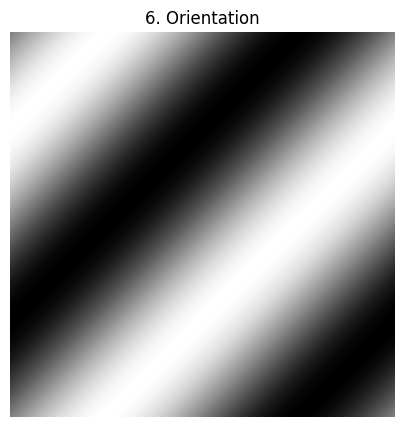

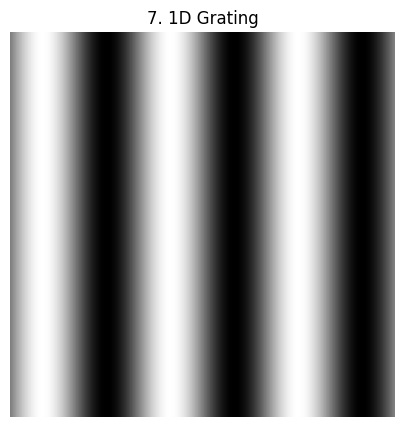

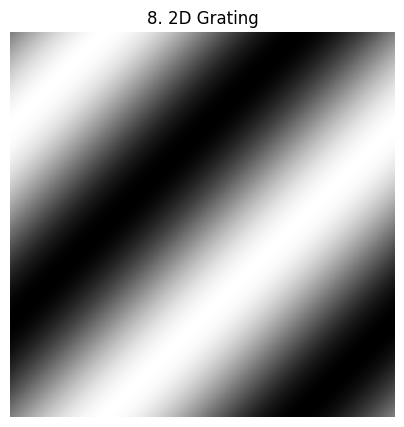

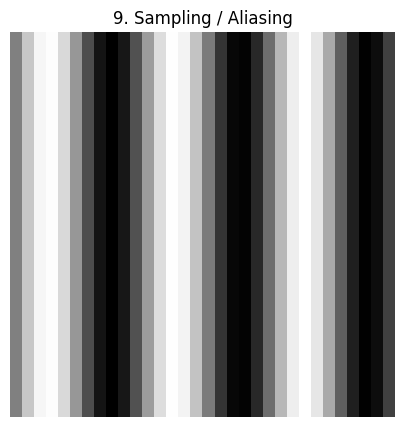

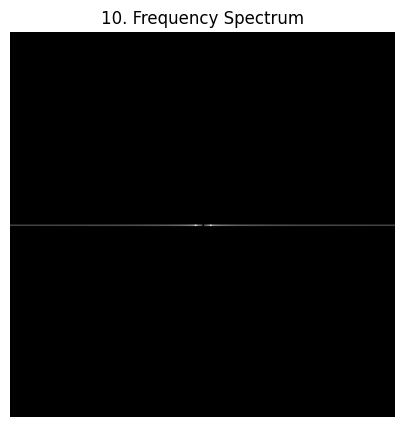

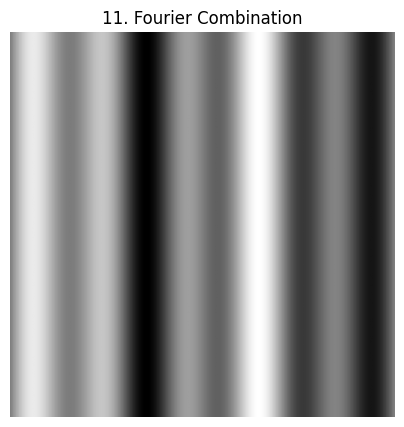

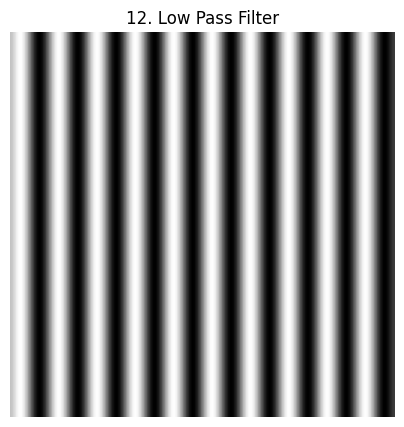

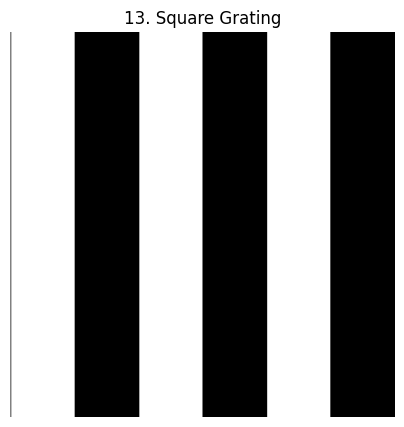

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# =========================
# GRID SETUP
# =========================
size = 256
x = np.linspace(0, 2*np.pi, size)
y = np.linspace(0, 2*np.pi, size)
X, Y = np.meshgrid(x, y)

# =========================
# ORIGINAL IMAGE
# =========================
original = 128 + 127*np.sin(X*3)

plt.figure(figsize=(5,5))
plt.imshow(original, cmap='gray')
plt.title("Original Sinusoidal Grating")
plt.axis('off')
plt.show()

# =========================
# GENERATE & DISPLAY EACH IMAGE SEPARATELY
# =========================

# 1
img1 = 128 + 127*np.sin(X*3)
plt.figure(figsize=(5,5))
plt.imshow(img1, cmap='gray')
plt.title("1. Sinusoidal Grating")
plt.axis('off')
plt.show()

# 2
img2 = 128 + 127*np.sin(2*np.pi*(0.5*X + 0.2*Y))
plt.figure(figsize=(5,5))
plt.imshow(img2, cmap='gray')
plt.title("2. Mathematical Representation")
plt.axis('off')
plt.show()

# 3
img3 = 128 + 127*np.sin(X*10)
plt.figure(figsize=(5,5))
plt.imshow(img3, cmap='gray')
plt.title("3. High Frequency")
plt.axis('off')
plt.show()

# 4
img4 = 128 + 50*np.sin(X*3)
plt.figure(figsize=(5,5))
plt.imshow(img4, cmap='gray')
plt.title("4. Low Contrast")
plt.axis('off')
plt.show()

# 5
img5 = 128 + 127*np.sin(X*3 + np.pi/2)
plt.figure(figsize=(5,5))
plt.imshow(img5, cmap='gray')
plt.title("5. Phase Shift")
plt.axis('off')
plt.show()

# 6
img6 = 128 + 127*np.sin(X + Y)
plt.figure(figsize=(5,5))
plt.imshow(img6, cmap='gray')
plt.title("6. Orientation")
plt.axis('off')
plt.show()

# 7
img7 = 128 + 127*np.sin(X*3)
plt.figure(figsize=(5,5))
plt.imshow(img7, cmap='gray')
plt.title("7. 1D Grating")
plt.axis('off')
plt.show()

# 8
img8 = 128 + 127*np.sin(X + Y)
plt.figure(figsize=(5,5))
plt.imshow(img8, cmap='gray')
plt.title("8. 2D Grating")
plt.axis('off')
plt.show()

# 9
img9 = 128 + 127*np.sin(X*3)
img9_sampled = img9[::8, ::8]
plt.figure(figsize=(5,5))
plt.imshow(img9_sampled, cmap='gray', interpolation='nearest')
plt.title("9. Sampling / Aliasing")
plt.axis('off')
plt.show()

# 10
img10 = np.sin(X*5)
fft = np.fft.fftshift(np.fft.fft2(img10))
fft_mag = np.log(np.abs(fft)+1)
plt.figure(figsize=(5,5))
plt.imshow(fft_mag, cmap='gray')
plt.title("10. Frequency Spectrum")
plt.axis('off')
plt.show()

# 11
img11 = np.sin(X*2) + np.sin(X*5)
plt.figure(figsize=(5,5))
plt.imshow(img11, cmap='gray')
plt.title("11. Fourier Combination")
plt.axis('off')
plt.show()

# 12
img12 = np.sin(X*10)
filtered = gaussian_filter(img12, sigma=3)
plt.figure(figsize=(5,5))
plt.imshow(filtered, cmap='gray')
plt.title("12. Low Pass Filter")
plt.axis('off')
plt.show()

# 13
square = np.sign(np.sin(X*3))
plt.figure(figsize=(5,5))
plt.imshow(square, cmap='gray')
plt.title("13. Square Grating")
plt.axis('off')
plt.show()

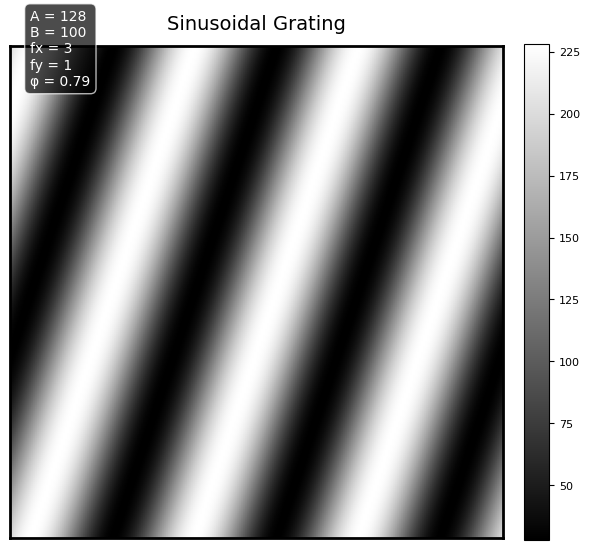

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128        # Average intensity
B = 100        # Amplitude
fx = 3         # Frequency (x)
fy = 1         # Frequency (y)
phi = np.pi/4  # Phase

# =========================
# GRID
# =========================
size = 256
x = np.linspace(0, 2*np.pi, size)
y = np.linspace(0, 2*np.pi, size)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
img = A + B * np.sin(fx*X + fy*Y + phi)

# =========================
# DISPLAY (BEAUTIFUL + BORDER)
# =========================
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(img, cmap='gray')

# Title
ax.set_title("Sinusoidal Grating", fontsize=14, pad=12)

# Remove ticks but keep border
ax.set_xticks([])
ax.set_yticks([])

# Draw clean border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# Parameter box (styled)
text = (
    f"A = {A}\n"
    f"B = {B}\n"
    f"fx = {fx}\n"
    f"fy = {fy}\n"
    f"φ = {round(phi,2)}"
)

ax.text(
    10, 20, text,
    color='white',
    fontsize=10,
    bbox=dict(
        facecolor='black',
        edgecolor='white',
        boxstyle='round,pad=0.4',
        alpha=0.7
    )
)

# Add colorbar (optional but looks good)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

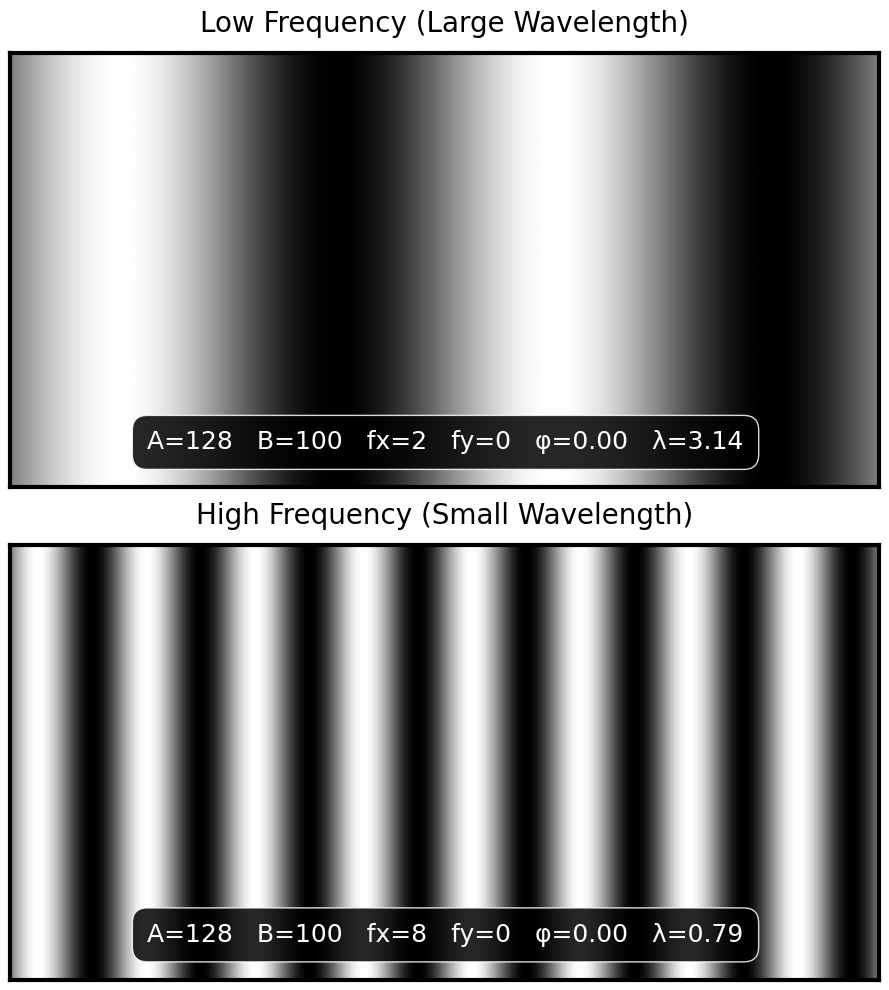

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
B = 100
fy = 0
phi = 0

fx1 = 2   # low frequency → large wavelength
fx2 = 8   # high frequency → small wavelength

# =========================
# GRID (1:2 aspect per image)
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
img1 = A + B * np.sin(fx1 * X + fy * Y + phi)
img2 = A + B * np.sin(fx2 * X + fy * Y + phi)

lambda1 = (2*np.pi) / fx1
lambda2 = (2*np.pi) / fx2

# =========================
# DISPLAY (VERTICAL STACK, UNBOLD TITLES)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

images = [img1, img2]
titles = ["Low Frequency (Large Wavelength)", "High Frequency (Small Wavelength)"]
params = [
    f"A={A}   B={B}   fx={fx1}   fy={fy}   φ={phi:.2f}   λ={lambda1:.2f}",
    f"A={A}   B={B}   fx={fx2}   fy={fy}   φ={phi:.2f}   λ={lambda2:.2f}"
]

for i in range(2):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')
    
    # Title (not bold)
    ax.set_title(titles[i], fontsize=20, pad=15)
    
    ax.set_xticks([])
    ax.set_yticks([])

    # Border
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Large parameter box
    ax.text(
        width//2, height-20, params[i],
        color='white',
        fontsize=18,
        ha='center',
        va='bottom',
        bbox=dict(facecolor='black', edgecolor='white', alpha=0.85, boxstyle='round,pad=0.6')
    )

plt.tight_layout()
plt.show()

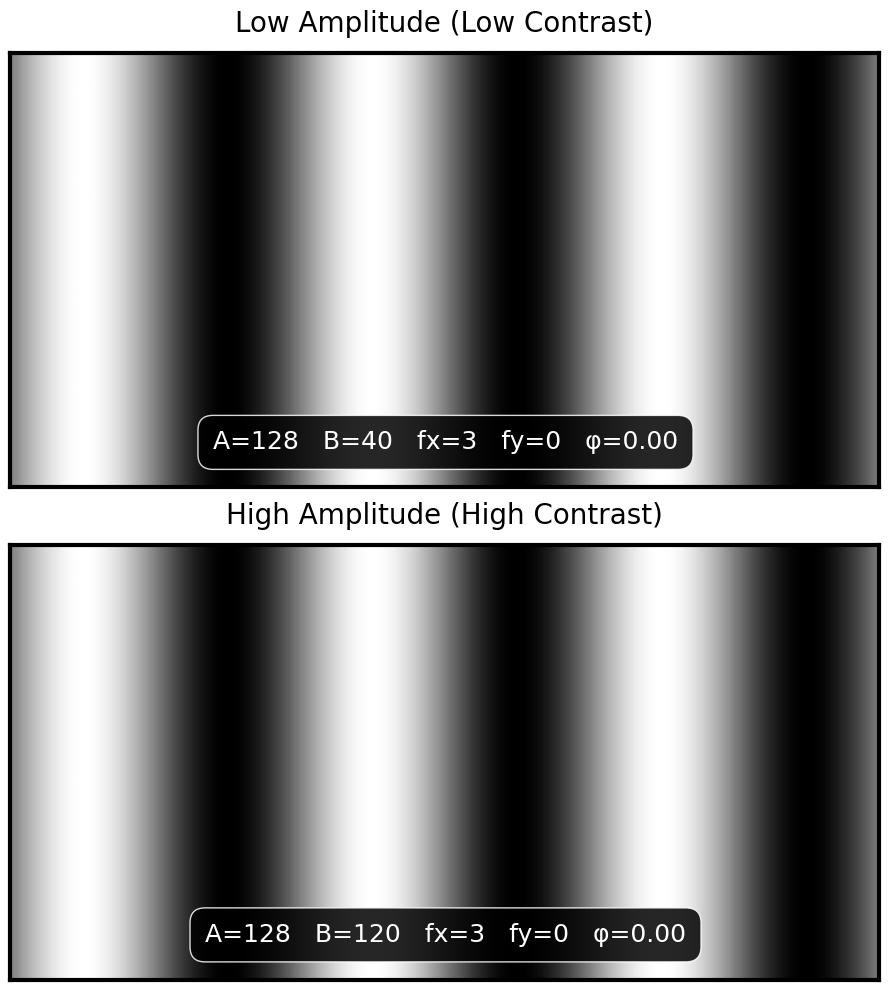

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
fx = 3
fy = 0
phi = 0

# Two amplitudes (→ contrast change)
B1 = 40    # low contrast
B2 = 120   # high contrast

# =========================
# GRID (1:2 aspect per image)
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
img1 = A + B1 * np.sin(fx * X + fy * Y + phi)
img2 = A + B2 * np.sin(fx * X + fy * Y + phi)

# =========================
# DISPLAY (VERTICAL STACK, STYLED)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

images = [img1, img2]
titles = ["Low Amplitude (Low Contrast)", "High Amplitude (High Contrast)"]
params = [
    f"A={A}   B={B1}   fx={fx}   fy={fy}   φ={phi:.2f}",
    f"A={A}   B={B2}   fx={fx}   fy={fy}   φ={phi:.2f}"
]

for i in range(2):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')

    # Title (clean, large, not bold)
    ax.set_title(titles[i], fontsize=20, pad=15)

    ax.set_xticks([])
    ax.set_yticks([])

    # Border styling
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Large parameter box (bottom center)
    ax.text(
        width//2, height-20, params[i],
        color='white',
        fontsize=18,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.6'
        )
    )

plt.tight_layout()
plt.show()

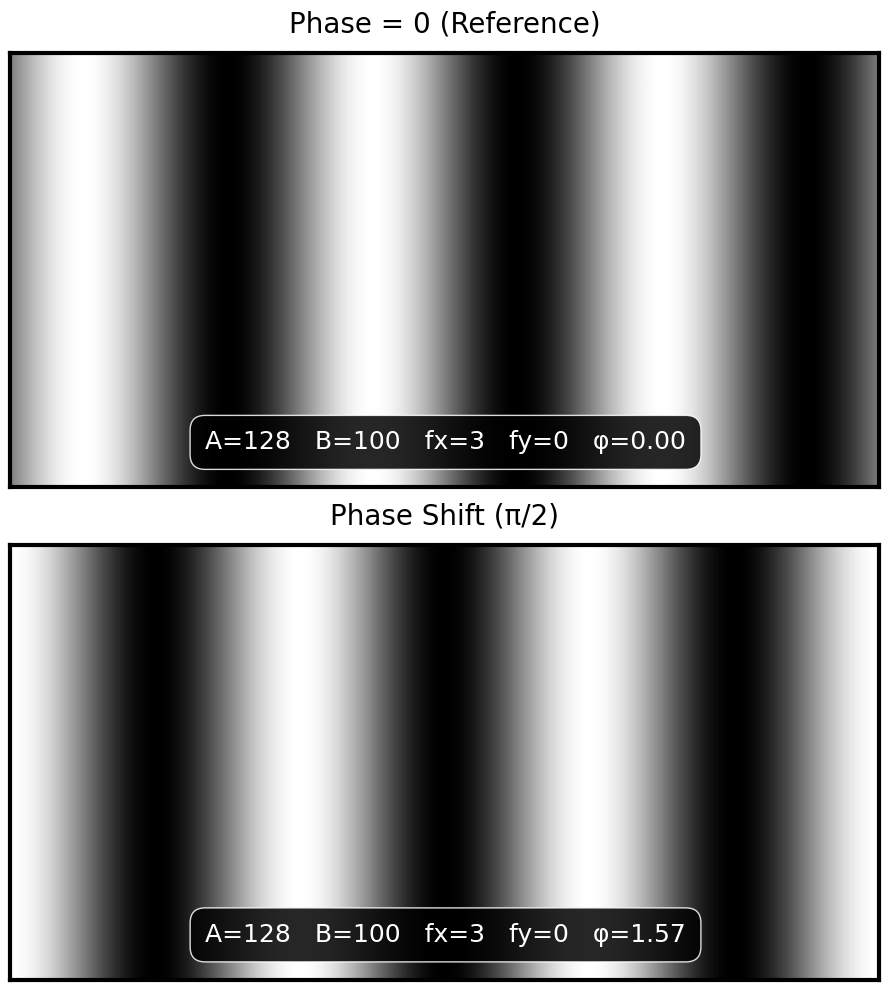

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
B = 100
fx = 3
fy = 0

# Two different phases
phi1 = 0
phi2 = np.pi / 2   # phase shift

# =========================
# GRID (1:2 aspect per image)
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
img1 = A + B * np.sin(fx * X + fy * Y + phi1)
img2 = A + B * np.sin(fx * X + fy * Y + phi2)

# =========================
# DISPLAY (VERTICAL STACK, STYLED)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

images = [img1, img2]
titles = ["Phase = 0 (Reference)", "Phase Shift (π/2)"]
params = [
    f"A={A}   B={B}   fx={fx}   fy={fy}   φ={phi1:.2f}",
    f"A={A}   B={B}   fx={fx}   fy={fy}   φ={phi2:.2f}"
]

for i in range(2):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')

    # Title (large, not bold)
    ax.set_title(titles[i], fontsize=20, pad=15)

    ax.set_xticks([])
    ax.set_yticks([])

    # Border styling
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Large parameter box (bottom center)
    ax.text(
        width//2, height-20, params[i],
        color='white',
        fontsize=18,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.6'
        )
    )

plt.tight_layout()
plt.show()

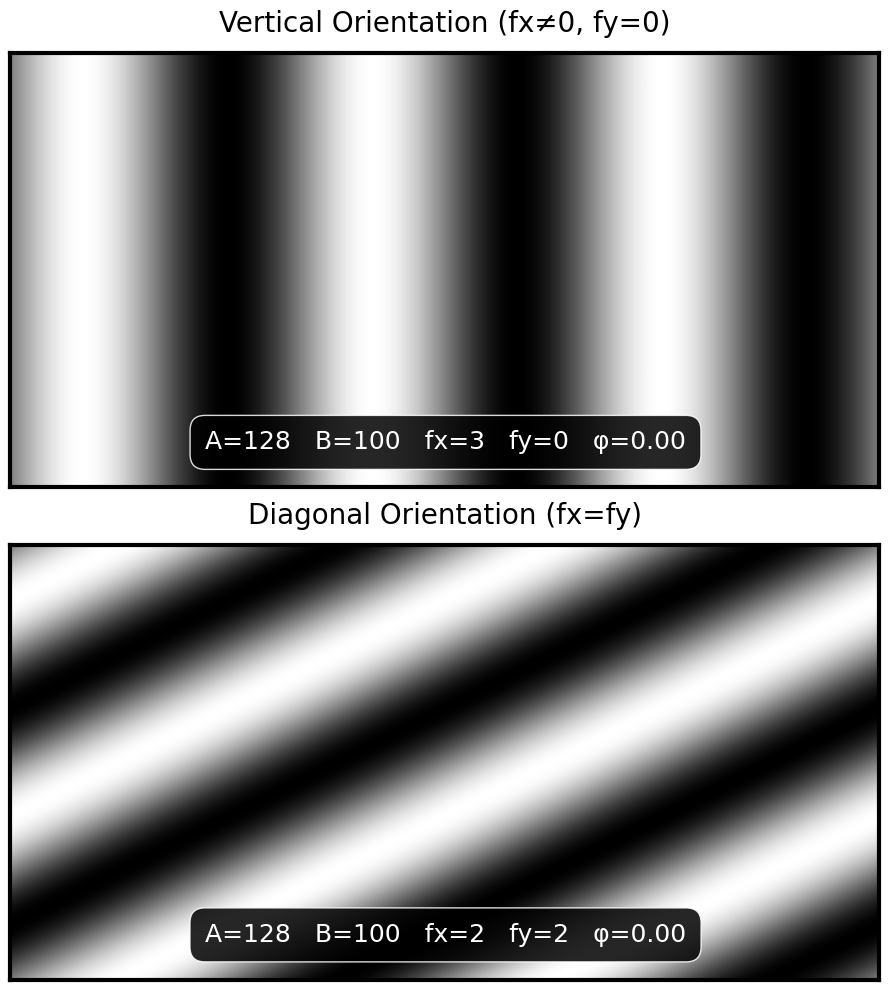

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
B = 100
phi = 0

# Orientation control via (fx, fy)
# Case 1: Vertical stripes (variation along x)
fx1, fy1 = 3, 0

# Case 2: Diagonal stripes (variation along x + y)
fx2, fy2 = 2, 2

# =========================
# GRID (1:2 aspect per image)
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
img1 = A + B * np.sin(fx1 * X + fy1 * Y + phi)
img2 = A + B * np.sin(fx2 * X + fy2 * Y + phi)

# =========================
# DISPLAY (VERTICAL STACK, STYLED)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

images = [img1, img2]
titles = ["Vertical Orientation (fx≠0, fy=0)", "Diagonal Orientation (fx=fy)"]
params = [
    f"A={A}   B={B}   fx={fx1}   fy={fy1}   φ={phi:.2f}",
    f"A={A}   B={B}   fx={fx2}   fy={fy2}   φ={phi:.2f}"
]

for i in range(2):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')

    # Title (large, not bold)
    ax.set_title(titles[i], fontsize=20, pad=15)

    ax.set_xticks([])
    ax.set_yticks([])

    # Border styling
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Large parameter box (bottom center)
    ax.text(
        width//2, height-20, params[i],
        color='white',
        fontsize=18,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.6'
        )
    )

plt.tight_layout()
plt.show()

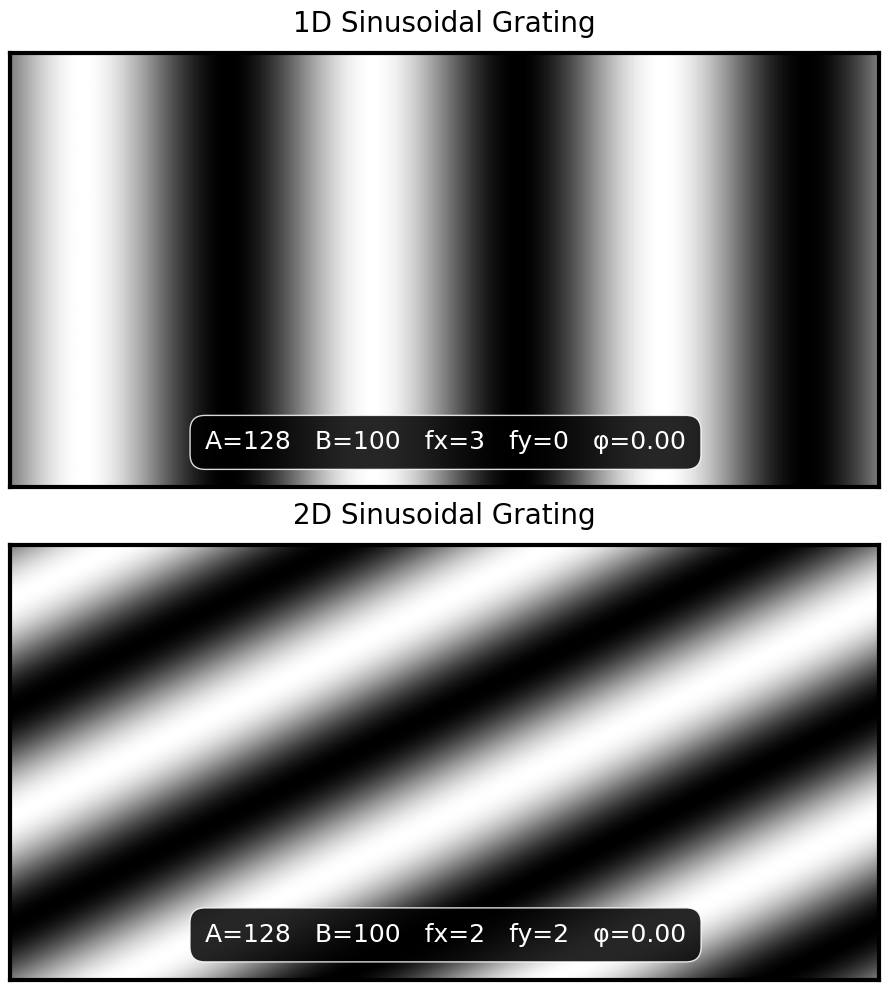

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
B = 100
phi = 0

# 1D vs 2D settings
# 1D: variation only along x
fx1, fy1 = 3, 0

# 2D: variation along both x and y
fx2, fy2 = 2, 2

# =========================
# GRID (1:2 aspect per image)
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
img1 = A + B * np.sin(fx1 * X + fy1 * Y + phi)  # 1D
img2 = A + B * np.sin(fx2 * X + fy2 * Y + phi)  # 2D

# =========================
# DISPLAY (VERTICAL STACK, STYLED)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

images = [img1, img2]
titles = ["1D Sinusoidal Grating", "2D Sinusoidal Grating"]
params = [
    f"A={A}   B={B}   fx={fx1}   fy={fy1}   φ={phi:.2f}",
    f"A={A}   B={B}   fx={fx2}   fy={fy2}   φ={phi:.2f}"
]

for i in range(2):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')

    # Title (large, not bold)
    ax.set_title(titles[i], fontsize=20, pad=15)

    ax.set_xticks([])
    ax.set_yticks([])

    # Border styling
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Large parameter box (bottom center)
    ax.text(
        width//2, height-20, params[i],
        color='white',
        fontsize=18,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.6'
        )
    )

plt.tight_layout()
plt.show()

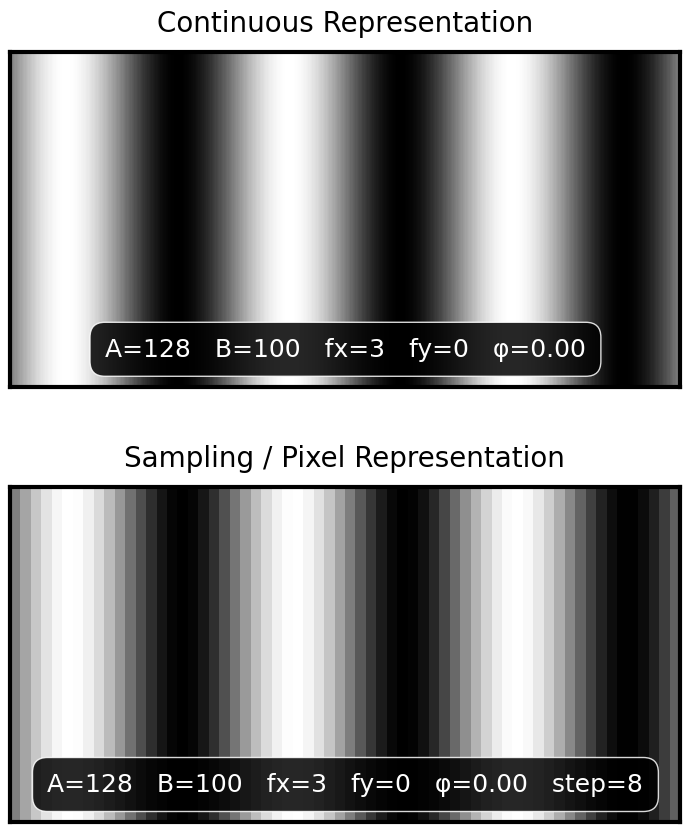

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
B = 100
fx = 3
fy = 0
phi = 0
sampling_step = 8

# =========================
# GRID (1:2 aspect per image)
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
# Continuous image
img1 = A + B * np.sin(fx * X + fy * Y + phi)

# Sampling (keep same size using block expansion)
img_small = img1[::sampling_step, ::sampling_step]
img2 = np.kron(img_small, np.ones((sampling_step, sampling_step)))

# =========================
# DISPLAY (VERTICAL STACK, SAME STYLE)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

images = [img1, img2]
titles = ["Continuous Representation", "Sampling / Pixel Representation"]
params = [
    f"A={A}   B={B}   fx={fx}   fy={fy}   φ={phi:.2f}",
    f"A={A}   B={B}   fx={fx}   fy={fy}   φ={phi:.2f}   step={sampling_step}"
]

for i in range(2):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray', interpolation='nearest')

    # Title (large, not bold)
    ax.set_title(titles[i], fontsize=20, pad=15)

    ax.set_xticks([])
    ax.set_yticks([])

    # Border styling
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Large parameter box (bottom center)
    ax.text(
        width//2, height-20, params[i],
        color='white',
        fontsize=18,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.6'
        )
    )

# Proper spacing (avoid tight_layout issue)
plt.subplots_adjust(hspace=0.3)

plt.show()

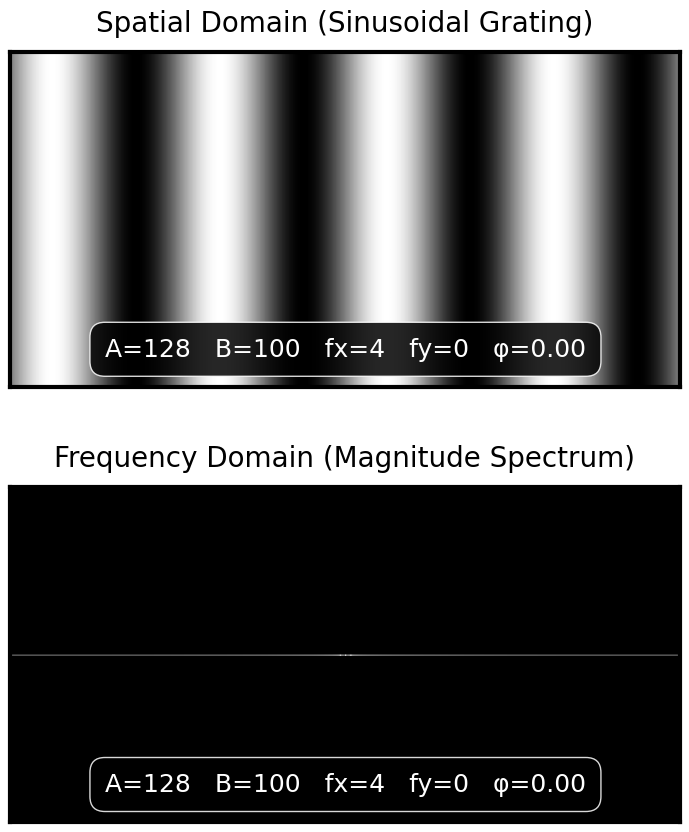

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
B = 100
fx = 4
fy = 0
phi = 0

# =========================
# GRID (1:2 aspect per image)
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
# Spatial domain image
img = A + B * np.sin(fx * X + fy * Y + phi)

# Frequency domain (FFT)
fft = np.fft.fftshift(np.fft.fft2(img))
fft_mag = np.log(np.abs(fft) + 1)

# =========================
# DISPLAY (VERTICAL STACK, STYLED)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

images = [img, fft_mag]
titles = ["Spatial Domain (Sinusoidal Grating)", "Frequency Domain (Magnitude Spectrum)"]
params = [
    f"A={A}   B={B}   fx={fx}   fy={fy}   φ={phi:.2f}",
    f"A={A}   B={B}   fx={fx}   fy={fy}   φ={phi:.2f}"
]

for i in range(2):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')

    # Title (large, not bold)
    ax.set_title(titles[i], fontsize=20, pad=15)

    ax.set_xticks([])
    ax.set_yticks([])

    # Border styling
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Large parameter box
    ax.text(
        width//2, height-20,
        params[i],
        color='white',
        fontsize=18,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.6'
        )
    )

# Proper spacing
plt.subplots_adjust(hspace=0.3)

plt.show()

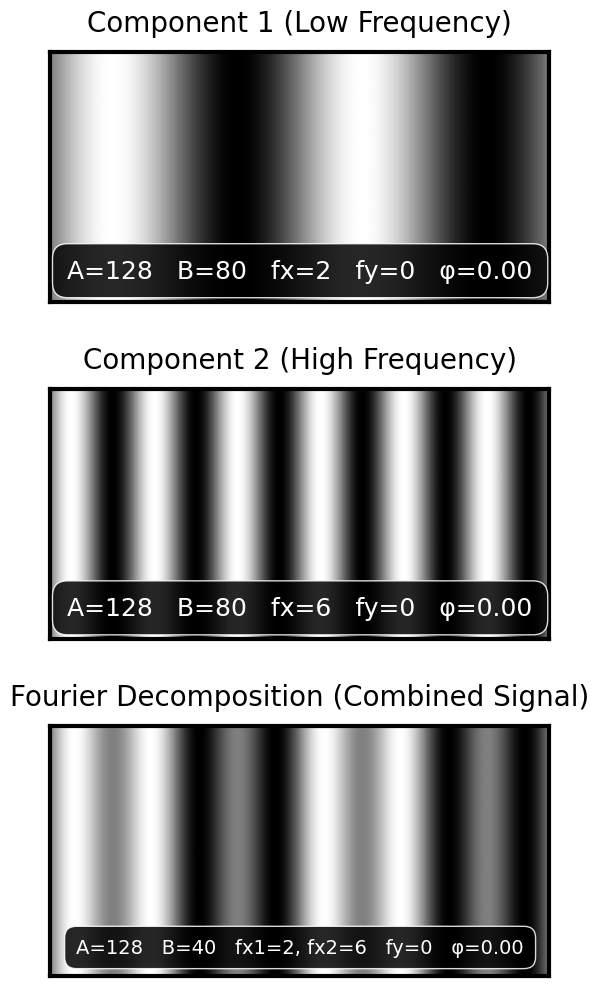

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
B = 80
phi = 0

fx1, fy1 = 2, 0
fx2, fy2 = 6, 0

# =========================
# GRID
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
img1 = A + B * np.sin(fx1 * X + fy1 * Y + phi)
img2 = A + B * np.sin(fx2 * X + fy2 * Y + phi)

combined = A + (B/2)*np.sin(fx1 * X + fy1 * Y + phi) + (B/2)*np.sin(fx2 * X + fy2 * Y + phi)

# =========================
# DISPLAY
# =========================
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

images = [img1, img2, combined]
titles = [
    "Component 1 (Low Frequency)",
    "Component 2 (High Frequency)",
    "Fourier Decomposition (Combined Signal)"
]

params = [
    f"A={A}   B={B}   fx={fx1}   fy={fy1}   φ={phi:.2f}",
    f"A={A}   B={B}   fx={fx2}   fy={fy2}   φ={phi:.2f}",
    f"A={A}   B={B/2:.0f}   fx1={fx1}, fx2={fx2}   fy={fy1}   φ={phi:.2f}"
]

for i in range(3):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')

    ax.set_title(titles[i], fontsize=20, pad=15)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Smaller text only for last image
    fontsize = 18 if i < 2 else 14

    ax.text(
        width//2, height-20,
        params[i],
        color='white',
        fontsize=fontsize,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.6'
        )
    )

plt.subplots_adjust(hspace=0.35)
plt.show()

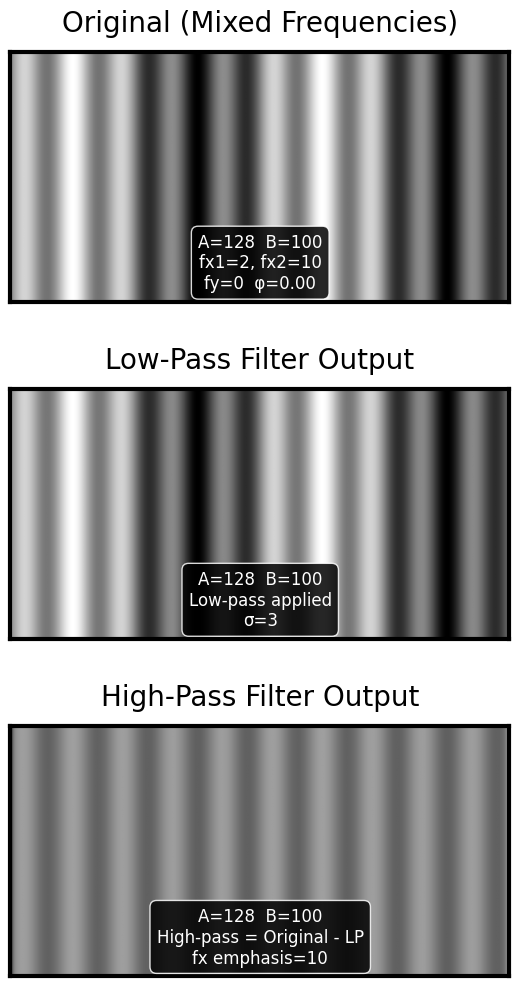

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# =========================
# PARAMETERS
# =========================
A = 128
B = 100
phi = 0

fx1, fy1 = 2, 0
fx2, fy2 = 10, 0

# =========================
# GRID
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGES
# =========================
img = A + (B/2)*np.sin(fx1*X + fy1*Y + phi) + (B/2)*np.sin(fx2*X + fy2*Y + phi)
low_pass = gaussian_filter(img, sigma=3)
high_pass = img - low_pass

# =========================
# DISPLAY
# =========================
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

images = [img, low_pass, high_pass]
titles = [
    "Original (Mixed Frequencies)",
    "Low-Pass Filter Output",
    "High-Pass Filter Output"
]

# Compact multi-line parameters (same size for all)
params = [
    f"A={A}  B={B}\nfx1={fx1}, fx2={fx2}\nfy={fy1}  φ={phi:.2f}",
    f"A={A}  B={B}\nLow-pass applied\nσ=3",
    f"A={A}  B={B}\nHigh-pass = Original - LP\nfx emphasis={fx2}"
]

for i in range(3):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray')

    ax.set_title(titles[i], fontsize=20, pad=15)
    ax.set_xticks([])
    ax.set_yticks([])

    # Border
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Compact parameter box (same size everywhere)
    ax.text(
        width//2, height-10,
        params[i],
        color='white',
        fontsize=12,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.4'
        )
    )

plt.subplots_adjust(hspace=0.35)
plt.show()

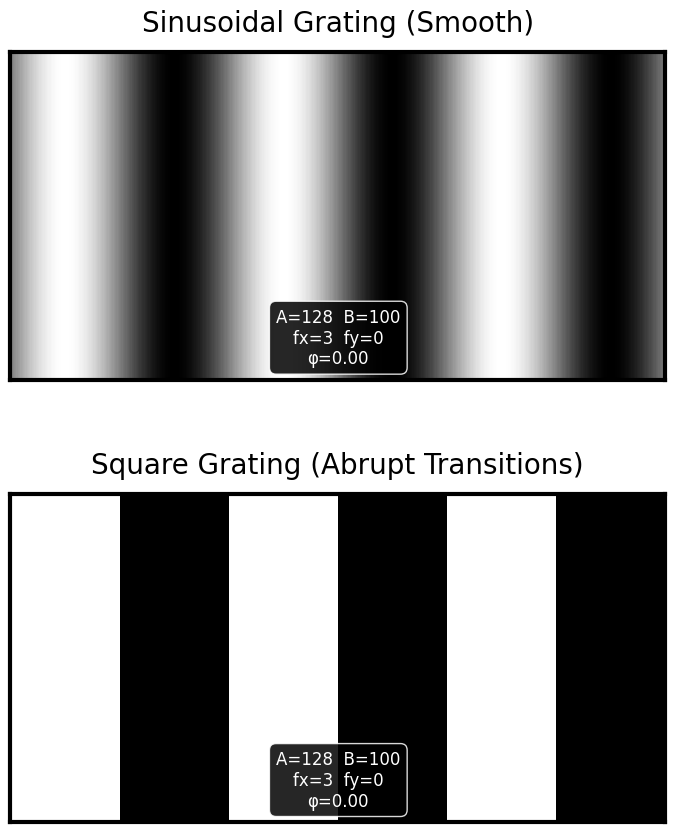

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
A = 128
B = 100
fx = 3
fy = 0
phi = 0

# =========================
# GRID (1:2 aspect per image)
# =========================
height = 256
width = 512

x = np.linspace(0, 2*np.pi, width)
y = np.linspace(0, 2*np.pi, height)
X, Y = np.meshgrid(x, y)

# =========================
# IMAGE GENERATION
# =========================
# Sinusoidal grating
sin_img = A + B * np.sin(fx * X + fy * Y + phi)

# Square grating (using sign of sine)
square_img = A + B * np.sign(np.sin(fx * X + fy * Y + phi))

# =========================
# DISPLAY (VERTICAL STACK, SAME STYLE)
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

images = [sin_img, square_img]
titles = ["Sinusoidal Grating (Smooth)", "Square Grating (Abrupt Transitions)"]

# Compact parameters (same size for both)
params = [
    f"A={A}  B={B}\nfx={fx}  fy={fy}\nφ={phi:.2f}",
    f"A={A}  B={B}\nfx={fx}  fy={fy}\nφ={phi:.2f}"
]

for i in range(2):
    ax = axes[i]
    ax.imshow(images[i], cmap='gray', interpolation='nearest')

    # Title (large, not bold)
    ax.set_title(titles[i], fontsize=20, pad=15)

    ax.set_xticks([])
    ax.set_yticks([])

    # Border styling
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(3)

    # Compact parameter box
    ax.text(
        width//2, height-10,
        params[i],
        color='white',
        fontsize=12,
        ha='center',
        va='bottom',
        bbox=dict(
            facecolor='black',
            edgecolor='white',
            alpha=0.85,
            boxstyle='round,pad=0.4'
        )
    )

plt.subplots_adjust(hspace=0.35)
plt.show()